# Exploración y análisis inicial - Ventas de lácteos 2024

Este notebook realiza un Análisis Exploratorio de Datos (EDA) del histórico de ventas proporcionado por la empresa distribuidora. El objetivo es comprender la estructura, calidad y comportamiento temporal del dataset para preparar el terreno antes de entrenar un modelo predictivo capaz de estimar cuántas unidades debería pedir la empresa el próximo mes, desglosadas por categoría → producto → presentación.

### 1. Importación de bibliotecas y carga de datos

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns


In [4]:
ruta = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'dataset_ventas_lacteos_2024.csv')
df = pd.read_csv(ruta)
display(df.head())

,ID Orden,Fecha,Nombre del vendedor,Nombre del supermercado,Representante de compras,Estado,Ciudad,Categoría,Producto,Presentación,Precio unitario (USD),Cantidad comprada,Valor total (USD),Forma de pago
0,1,11/03/2024,Zeller Sophie,Exquisite Foods Market,Rogers Harper,California,San Diego,Quesos,Queso en lonchas,Paquete 200g,3.80,543,2063.40,Tarjeta de crédito
1,2,26/07/2024,Smith Noah,The Food Barn,Tremblay Ana,Florida,Tampa,Otros,Suero de leche,Botella 1L,2.00,334,668.00,Tarjeta de débito
2,3,12/01/2024,Zeller Sophie,The Grocery Store,McBride Evelyn,California,San Diego,Quesos,Queso blanco,Bloque 500g,5.00,73,365.00,Tarjeta de débito
3,4,03/06/2024,Williams Chloe,Select Market,Bélanger Theodore,Nueva York,New York City,Yogur,Kumis,Botella 1L,2.50,658,1645.00,Efectivo
4,5,04/11/2024,Davis Olivia,Super Everything,Fraser Michael,California,San Francisco,Mantequilla,Mantequilla clarificada (ghee),Frasco 300ml,5.75,667,3835.25,PayPal


### 2. Entendiendo el dataset

#### 2.1 Información estructural

In [6]:
print("Nº de filas: ", df.shape[0])
print("Nº de columnas: ", df.shape[1])

Nº de filas:  10000
Nº de columnas:  14


In [7]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
ID Orden                      int64
Fecha                        object
Nombre del vendedor          object
Nombre del supermercado      object
Representante de compras     object
Estado                       object
Ciudad                       object
Categoría                    object
Producto                     object
Presentación                 object
Precio unitario (USD)       float64
Cantidad comprada             int64
Valor total (USD)           float64
Forma de pago                object
dtype: object


La única observación que se puede hacer de momento es que el campo **Fecha** debería pasarse a tipo `datetime`. El resto de columnas de tipo object deberían convertirse a tipo `string`.

Por lo que podemos apreciar, para nuestro modelo predictivo, la variable objetivo será la variable **Cantidad comprada**.

#### 2.2 Calidad de los datos

No hay valores nulos en el dataset

In [8]:
print("\nValores nulos por columna:")
print(df.isna().sum())


Valores nulos por columna:
ID Orden                    0
Fecha                       0
Nombre del vendedor         0
Nombre del supermercado     0
Representante de compras    0
Estado                      0
Ciudad                      0
Categoría                   0
Producto                    0
Presentación                0
Precio unitario (USD)       0
Cantidad comprada           0
Valor total (USD)           0
Forma de pago               0
dtype: int64


Tampoco tenemos columnas donde todos los valores sean iguales

In [9]:
zero_var = df.columns[df.nunique() <= 1]
zero_var

Index([], dtype='object')

No existen filas duplicadas

In [10]:
(df.duplicated().sum() / len(df)) * 100

np.float64(0.0)

Y no tenemos valores negativos en columnas que no deberían tenerlos

In [12]:
cols_no_neg = ['Precio unitario (USD)', 'Cantidad comprada', 'Valor total (USD)']

ilegal_neg = {col: df[df[col] < 0][col] for col in cols_no_neg}
ilegal_neg


{'Precio unitario (USD)': Series([], Name: Precio unitario (USD), dtype: float64),
 'Cantidad comprada': Series([], Name: Cantidad comprada, dtype: int64),
 'Valor total (USD)': Series([], Name: Valor total (USD), dtype: float64)}

#### 2.3 Corrección tipo de datos

Vamos a realizar los cambios mencionados en el apartado 2.1

In [13]:
# Convertir Fecha a datetime (formato dd/mm/yyyy)
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%Y")

In [14]:
cols_texto = ["Categoría", "Producto", "Presentación"]

df[cols_texto] = df[cols_texto].astype("string")

### 3. Análisis Univariante

#### 3.1 Variables numéricas

In [15]:
df_describe = df[["Precio unitario (USD)", "Cantidad comprada", "Valor total (USD)"]].describe()
display(df_describe)

,Precio unitario (USD),Cantidad comprada,Valor total (USD)
count,10000.000000,10000.000000,10000.000000
mean,3.249372,498.720600,1620.502492
std,1.592033,286.615413,1311.470311
min,0.650000,10.000000,15.000000
25%,2.000000,251.000000,588.000000
50%,3.000000,493.000000,1250.000000
75%,4.200000,746.250000,2334.000000
max,6.250000,1000.000000,6237.500000


Observaciones:

- Precio unitario (USD)

    Distribución relativamente amplia: oscila entre 0.65 y 6.25, lo cual es normal en productos de alimentación congelada donde hay diferentes presentaciones o categorías.

    La mediana (3.0) está muy cerca de la media → no hay una asimetría fuerte.

    No hay valores negativos ni sospechosamente altos → no parecen haber errores de registro.

- Cantidad comprada

    La mediana (493) es muy cercana a la media (498) → la distribución no está sesgada.

    El mínimo es 10, claramente diferente del resto → probablemente representa pedidos muy pequeños.

    El máximo está en 1000, lo cual suena razonable para compras "por caja múltiple" típicas en mayoristas.

- Valor total (USD)

    Alta dispersión: El rango de valores va desde pedidos de 15 USD hasta pedidos de más de 6000 USD.

    La mediana (1236) está por debajo de la media (1613) → cola derecha (hay pedidos grandes que empujan la media hacia arriba).

    Esto es normal: algunos clientes compran a granel (hostelería, supermercados), mientras otros compran menos.

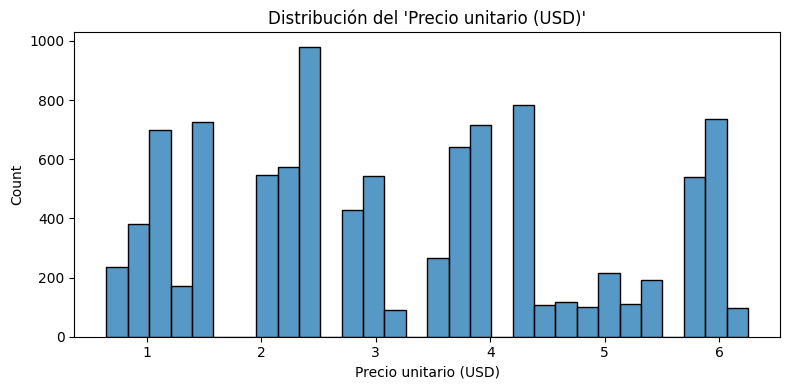

In [19]:
# Distribución del valor total
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Precio unitario (USD)"], bins=30, ax=ax)
ax.set_title("Distribución del 'Precio unitario (USD)'")
ax.set_xlabel("Precio unitario (USD)")
plt.tight_layout()
plt.show()

La distribución del Precio unitario muestra una elevada variabilidad, con valores que oscilan aproximadamente entre 0,8 USD y más de 6 USD, lo que indica que no existe un precio fijo y que el dataset contiene productos de distintas gamas. La forma multimodal del histograma revela varios grupos bien diferenciados de precios, probablemente asociados a diferentes tipos de producto o presentación

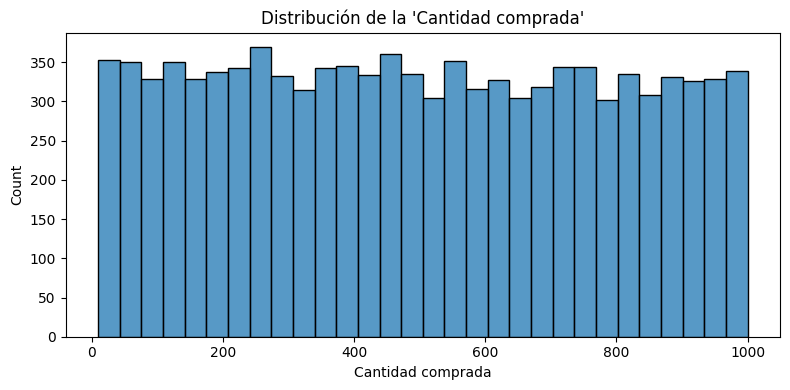

In [20]:
# Distribución de cantidad comprada
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Cantidad comprada"], bins=30, ax=ax)
ax.set_title("Distribución de la 'Cantidad comprada'")
ax.set_xlabel("Cantidad comprada")
plt.tight_layout()
plt.show()

El histograma muestra una forma casi rectangular, con barras muy similares en altura, desde cantidades pequeñas hasta cantidades grandes. Algo poco común en datos de ventas.

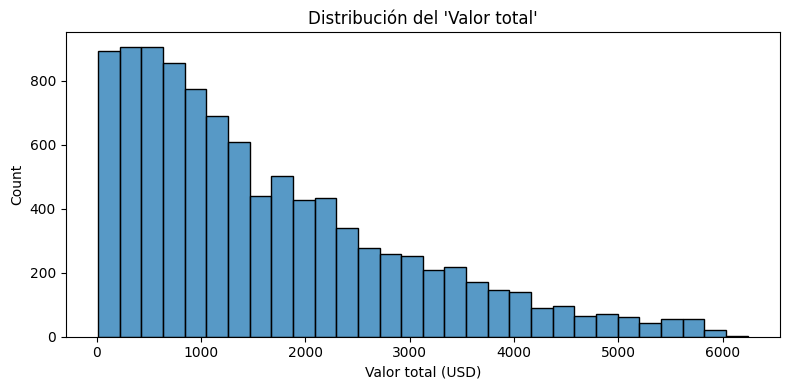

In [21]:
# Distribución del valor total
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Valor total (USD)"], bins=30, ax=ax)
ax.set_title("Distribución del 'Valor total'")
ax.set_xlabel("Valor total (USD)")
plt.tight_layout()
plt.show()

- cola larga hacia la derecha

- acumulación fuerte en los valores pequeños

- decrecimiento exponencial conforme aumenta el importe

Los pequeños clientes compran mucho más a menudo que los grandes compradores.

#### 3.2 Variables categóricas

In [22]:
print("Nº de categorías:", df["Categoría"].nunique())
print("Nº de productos:", df["Producto"].nunique())
print("Nº de presentaciones:", df["Presentación"].nunique())

Nº de categorías: 6
Nº de productos: 39
Nº de presentaciones: 28


In [23]:
print("\nFrecuencia de los valores de la variable 'Categoría':")
display(df["Categoría"].value_counts())



Frecuencia de los valores de la variable 'Categoría':


Categoría
Mantequilla    1712
Leche          1691
Otros          1677
Quesos         1659
Yogur          1640
Cremas         1621
Name: count, dtype: Int64

Vemos que en el conjunto de datos no hay categorías "raras" o poco representadas

In [24]:
raras = df['Categoría'].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras


Series([], Name: proportion, dtype: Float64)

Para saber cuán diversas son las categorías de productos lácteos en el dataset calculamos la entropía, de esta forma podemos medir qué tan diversa o uniforme es la distribución de las categorías de esta columna. Para ello se usará la siguiente fórmula:

$$H = -\sum_{i=1}^{n} p_i \cdot \log_2(p_i)$$

- Entropía alta → las categorías están distribuidas de forma muy uniforme, hay mucha variedad.
- Entropía baja → pocas categorías dominan, hay poca variedad.
- Entropía = 0 → todos los valores son de la misma categoría.

In [25]:
def entropy(col):
    proportions = col.value_counts(normalize=True)
    return -np.sum(proportions * np.log2(proportions))

entropia_categoria = entropy(df['Categoría'])
entropia_categoria

np.float64(2.5847196477592393)

El valor máximo posible de entropía depende del número de categorías únicas.
Para `n` categorías, la entropía máxima sería $\log_2(n)$.

Como tenemos 6 categorías, la entropía máxima sería log₂(6) ≈ 2.58 bits, que coincide con nuestro resultado. Por tanto, la columna   `Categoria` tiene distribución perfectamente uniforme.

Hagamos el mismo estudio para la coluna `Producto`.

In [26]:
print("\nFrecuencia de cada tipo de 'Producto':")
display(df["Producto"].value_counts())


Frecuencia de cada tipo de 'Producto':


Producto
Mantequilla con sal               591
Mantequilla sin sal               581
Mantequilla clarificada (ghee)    540
Suero de leche                    446
Dulce de leche                    435
Yogur griego                      434
Queso crema                       427
Yogur con frutas                  417
Cuajada                           404
Yogur natural                     402
Crema agria                       401
Crema de leche                    398
Crema batida                      395
Helado                            392
Kumis                             387
Leche entera                      203
Leche saborizada                  201
Leche en polvo                    194
Leche condensada                  192
Bebidas lácteas                   189
Leche descremada                  188
Leche deslactosada                182
Leche evaporada                   171
Leche semidescremada              171
Queso ricota                      126
Queso mozzarella                  125
Que

Hay 3 productos con presencia muy baja en el dataset, todos por debajo del 1%: Queso azul roquefort (0.98%), Queso blanco (0.97%) y Queso para untar (0.91%). Son productos que se venden muy poco en comparación con el resto.

In [27]:
raras = df['Producto'].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras


Producto
Queso azul roquefort    0.0098
Queso blanco            0.0097
Queso para untar        0.0091
Name: proportion, dtype: Float64

El valor de 5.03 bits es muy cercano al máximo teórico para 39 categorías, que sería log₂(39) ≈ 5.29 bits. Esto indica que, a pesar de los 3 productos minoritarios detectados, la distribución general es bastante uniforme, es decir, la mayoría de los 39 productos tienen una presencia similar en el dataset y no hay un producto que domine de forma clara.

In [28]:
entropia_producto = entropy(df['Producto'])
entropia_producto

np.float64(5.025554978935216)

In [29]:
print("\nFrecuencia de las combinaciones Producto + Presentación:")
display(
    df.groupby(["Producto", "Presentación"])["ID Orden"]
    .count()
    .sort_values(ascending=False)
)


Frecuencia de las combinaciones Producto + Presentación:


Producto                        Presentación    
Mantequilla con sal             Paquete 454g        591
Mantequilla sin sal             Paquete 454g        581
Mantequilla clarificada (ghee)  Frasco 300ml        540
Suero de leche                  Botella 1L          446
Dulce de leche                  Frasco 250g         435
Yogur griego                    Individual          434
Queso crema                     Tarrina 250g        427
Yogur con frutas                Individual          417
Cuajada                         Envase 250g         404
Crema agria                     Tarrina 200g        401
Crema de leche                  Cartón 946ml        398
Crema batida                    Spray 250ml         395
Kumis                           Botella 1L          387
Yogur natural                   Individual          207
Helado                          Tarrina 500ml       201
Yogur natural                   Familiar 1L         195
Leche condensada                Lata 397g           192

 Hay 12 combinaciones de Producto-Presentación que aparecen menos del 1% de las veces. Destacan productos como Leche entera, que aparece en 3 presentaciones poco frecuentes (Galón, Individual y Litro), lo que podría indicar que esas presentaciones no son las habituales para ese producto. También aparecen varios quesos y leches descremadas con presentaciones muy específicas y poco vendidas.

In [33]:
raras = df[["Producto", "Presentación"]].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras

Producto              Presentación 
Queso azul roquefort  Cuña 150g        0.0098
Queso blanco          Bloque 500g      0.0097
Leche semidescremada  Litro            0.0092
Queso para untar      Tarrina 250g     0.0091
Bebidas lácteas       Botella 500ml    0.0089
Leche descremada      Individual       0.0088
Leche en polvo        Bolsa 800g       0.0086
Leche semidescremada  Individual       0.0079
Leche deslactosada    Individual       0.0074
Leche entera          Galón            0.0071
                      Individual       0.0070
                      Litro            0.0062
Name: proportion, dtype: float64

El valor de 5.25 bits es muy cercano al máximo teórico. Si hay 39 productos × 28 presentaciones, no todas las combinaciones son válidas en la práctica, pero el resultado sugiere que las combinaciones Producto-Presentación están distribuidas de forma bastante uniforme, sin que ninguna combinación concreta domine claramente sobre las demás.

In [34]:
col_combinada = df["Producto"] + " - " + df["Presentación"]
entropia_categoria = entropy(col_combinada)
entropia_categoria

np.float64(5.248718402009573)